# Libraries

## I/O

In [1]:
import os
from pprint import pprint
import pickle

from util_IO import (
    load_pickle_from_main_project_dir,
    get_mlflow_tracking_uri
)

import gc

## Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.backend import clear_session
import mlflow

import shap

2025-06-10 09:11:44.397409: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-10 09:11:47.115678: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/lib/x86_64-linux-gnu/:/opt/conda/lib
2025-06-10 09:11:47.115917: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local

# Settings

## Packages

In [3]:
# Set pandas to display a maximum of 300 columns
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 1000)

# Suppress the SettingWithCopyWarning
pd.options.mode.chained_assignment = None

# Set mlflow server
mlflow.set_tracking_uri(
    uri=get_mlflow_tracking_uri()
)

# Define the client
client = mlflow.tracking.MlflowClient()

## Parameters

### Load metadata from *1-DataAggregation.ipynb*

In [4]:
aggr_parameters_dict, camels_gb_use_case_dir = load_pickle_from_main_project_dir(
    'aggr_parameters_dict.pkl'
)

# # Print imported variable
pprint(aggr_parameters_dict)

{'attributes': {'aggregations': {'fundamental': {'chalk_streams_df': ['chalk_stream_flag'],
                                                 'climatic_attributes_df': [],
                                                 'humaninfluence_attributes_df': ['surfacewater_abs',
                                                                                  'groundwater_abs',
                                                                                  'discharges',
                                                                                  'num_reservoir',
                                                                                  'reservoir_cap'],
                                                 'hydrogeology_attributes_df': [],
                                                 'hydrologic_attributes_df': ['baseflow_index'],
                                                 'hydrometry_attributes_df': ['bankfull_flow'],
                                                 'landc

In [5]:
# Variables picked
camels_gb_silver_dir = aggr_parameters_dict['camels_gb_silver_dir']

## MLflow

### Define functions

In [6]:
def get_experiments():
    experiments = client.search_experiments()
    return [exp for exp in experiments if exp.name.startswith("w")]

def load_model(run_id):
    model_uri = f"runs:/{run_id}/model"
    model = mlflow.keras.load_model(f"runs:/{run_id}/model")
    return model

# XML

## Overall

w30-log1p_discharge_vol-1985-bfi_Y-cs_Y_csf-N
w30-log1p_discharge_vol-1985-bfi_N-cs_Y_csf-Y
w30-discharge_vol-1985-bfi_Y-cs_Y_csf-Y
w30-discharge_vol-1985-bfi_Y-cs_Y_csf-N


2025-06-10 09:15:32.722711: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-06-10 09:15:32.726155: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-06-10 09:15:32.729506: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-06-10 09:15:32.732767: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-06-10 09:15:33.024806: I tensorflow/compiler/xla/stream_executo

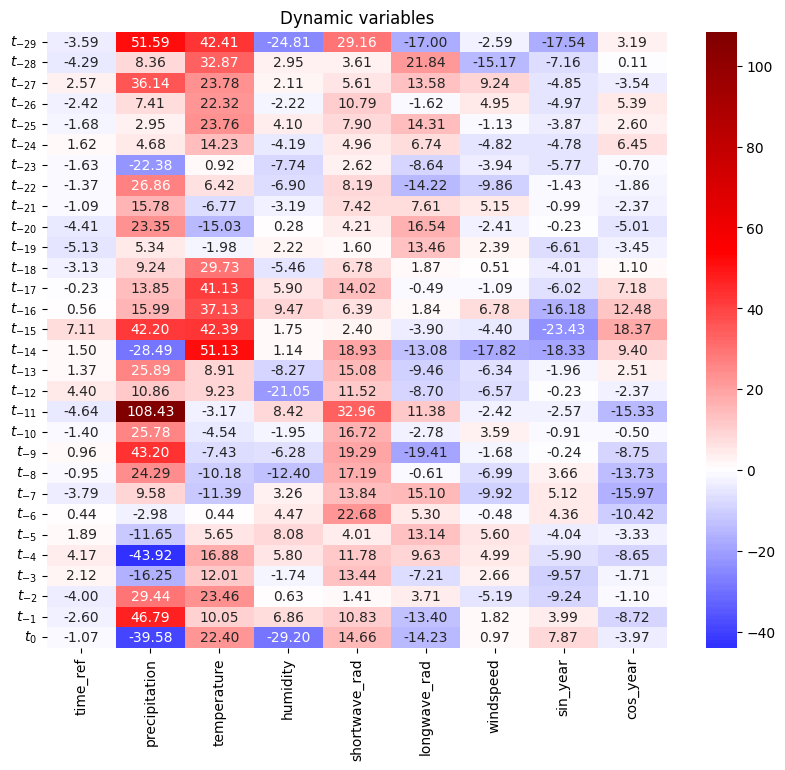

TypeError: cannot unpack non-iterable Axes object

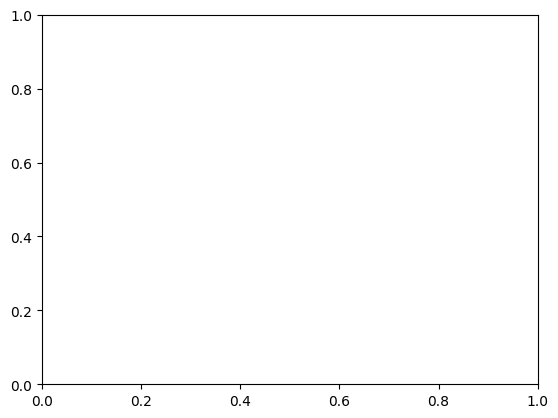

In [8]:
# Retrieve use cases experiments
experiments = get_experiments()

# Loop on experiments
for experiment in experiments:

    # Get experiment name
    experiment_name = experiment.name
    print(experiment_name)

    # ⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
    if experiment_name != "w30-discharge_vol-1985-bfi_Y-cs_Y_csf-N":
        continue

    
    # Read file with training data
    with open(
        os.path.join(
            camels_gb_silver_dir,
            f"model_feed-{experiment_name}.pkl"
        ),
        'rb'
    ) as f:
        model_feed = pickle.load(f)

    
    # ____________________
    # Dataset manipulation
    
    # Convert to arrays
    X_train_full = np.array(model_feed['X_train'], dtype=np.float32)
    X_train_static_full = np.array(model_feed['X_train_static_df'].values, dtype=np.float32)

    # Sample of the data
    sample_frac = 0.01
    sample_size = int(sample_frac * X_train_full.shape[0])
    np.random.seed(82)
    sample_indices = np.random.choice(
        X_train_full.shape[0],
        size=sample_size,
        replace=False
    )
    
    # Subset the data
    X_train = X_train_full[sample_indices]
    X_train_static = X_train_static_full[sample_indices]

    
    # _____________________
    # Column names settings
    
    X_cols_names = model_feed['X_cols_names']
    X_static_cols_names = model_feed['X_static_cols_names']
    
    # Set rows and columns labels for graphs for time series 3D to 2D matrix
    ts_row_labels = [f"$t_{{{-i}}}$" for i in range(X_train.shape[1] - 1, -1, -1)]
    ts_column_labels = X_cols_names

    # ________________
    # Analysis on runs
    
    # Get runs for the current experiment
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])

    # Identify runs with model stored
    runs_with_model = []
    for run in runs:
        artifacts = client.list_artifacts(run.info.run_id)
        if any(artifact.path == "model" for artifact in artifacts):
            runs_with_model.append(run)

    # Loop on runs with model stored
    for run in runs_with_model:
    
        # Retrieve the model
        model = load_model(run.info.run_id)

        # TF - Clear session
        clear_session()

        # Define the explainer
        explainer = shap.GradientExplainer(
            model,
            [X_train, X_train_static]
        )

        # Retrieving shap values
        shap_values = explainer.shap_values(
            [X_train, X_train_static]
        )

        # Reshape shap values where needed
        shap_values_dynamic = np.sum(shap_values[0][0], axis=0)
        shap_values_static = shap_values[0][1]

        
        # ___________________
        # Time series heatmap

        # Create the heatmap
        fig = plt.figure(figsize=(10, 8))
        sns.heatmap(
            shap_values_dynamic,
            annot=True,
            fmt=".2f",
            xticklabels=ts_column_labels,
            yticklabels=ts_row_labels,
            cmap='seismic',
            center=0
        )
        plt.title("Dynamic variables")
        plt.show()

        # Log in mlflow
        client.log_figure(
            run_id=run.info.run_id,
            figure=fig,
            artifact_file='XML/DynamicVar_Heatmap.png'
        )

        
        # ____________________
        # Attributes bar chart
        
        # Create a new figure
        fig, ax = plt.subplot()
        
        # Plot the SHAP summary plot for attributes
        shap.summary_plot(
            shap_values_static,
            feature_names=X_static_cols_names,
            ax=ax
        )

        # Log in mlflow
        client.log_figure(
            run_id=run.info.run_id,
            figure=fig,
            artifact_file='XML/StaticVar_BarChart.png'
        )

        
        # _______________________________
        # Deletion and garbage collection
        del model
        gc.collect()